In [1]:
! git clone https://github.com/mnedo/SMADIMO_GP2/

Cloning into 'SMADIMO_GP2'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 218 (delta 60), reused 19 (delta 19), pack-reused 129 (from 1)
Receiving objects: 100% (218/218), 6.10 MiB | 14.50 MiB/s, done.
Resolving deltas: 100% (107/107), done.


In [2]:
pip install openpyxl

In [3]:
import pandas as pd

cities_before = pd.read_excel('SMADIMO_GP2/data/cities_before.xlsx')
cities_before.head()

,Unnamed: 0,Город,Регион,Федеральный округ,Население,Наличие аэропорта
0,0,Абаза,Хакасия,Сибирский,12272,False
1,1,Абакан,Хакасия,Сибирский,184284,True
2,2,Абдулино,Оренбургская область,Приволжский,17274,False
3,3,Абинск,Краснодарский край,Южный,38440,False
4,4,Агидель,Башкортостан,Приволжский,14219,False


In [4]:
cities_before_aero = cities_before.groupby('Федеральный округ')['Наличие аэропорта'].sum()

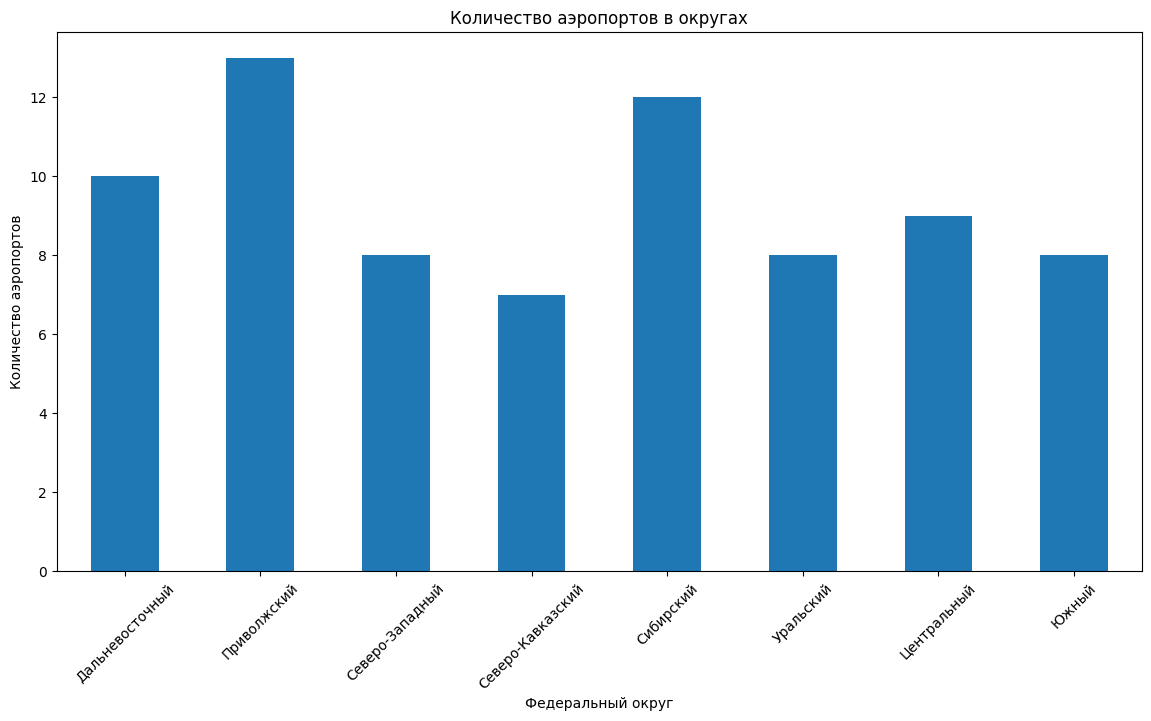

In [5]:
import matplotlib.pyplot as plt

cities_before_aero = cities_before.groupby('Федеральный округ')['Наличие аэропорта'].sum()

plt.figure(figsize=(14, 7))
cities_before_aero.plot(kind='bar')

plt.title('Количество аэропортов в округах')
plt.xlabel('Федеральный округ')
plt.ylabel('Количество аэропортов')
plt.xticks(rotation=45)
plt.show()

In [6]:
a = cities_before.groupby('Регион')['Наличие аэропорта'].sum().sort_values()
cities1 = cities_before[cities_before['Регион'].isin(a[a == 0].index)]
big = len(cities_before)
small = len(cities1)

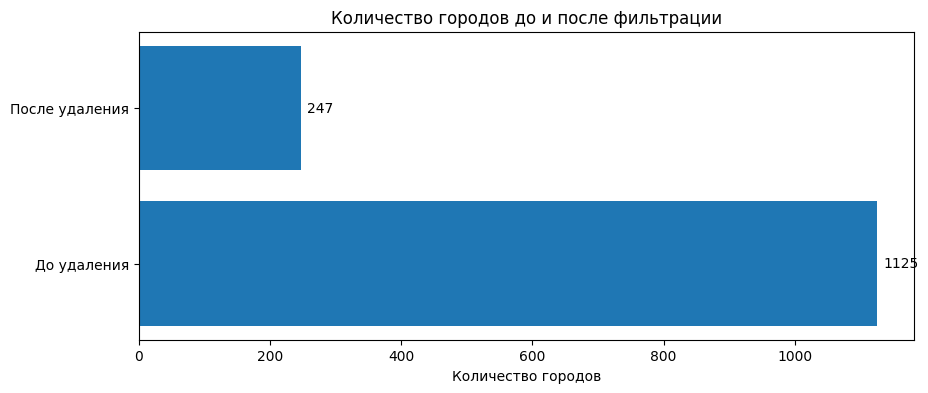

In [7]:
import matplotlib.pyplot as plt

labels = ['До удаления', 'После удаления']
values = [big, small]
plt.figure(figsize=(10, 4))
plt.barh(labels, values)
plt.title('Количество городов до и после фильтрации')
plt.xlabel('Количество городов')
plt.text(big + 10, 'До удаления', str(big), va='center')
plt.text(small + 10, 'После удаления', str(small), va='center')
plt.show()

In [9]:
hotels_w = pd.read_excel('SMADIMO_GP2/data/results.xlsx')

In [10]:
hotels_w = hotels_w.rename(columns={'rating_weighted': 'target'})

In [11]:
city_corr = hotels_w.groupby(by=['city_name']).agg({'price_per_night': 'mean', 'Интересные здания': 'mean',	'Музеи': 'mean',	'Природные достопримечательности': 'mean',	'Рестораны': 'mean', 'Театры': 'mean', 'flight_price_weighted': 'mean',	'target': 'mean'}).reset_index()

In [12]:
city_corr['weighted_score'] = (city_corr['flight_price_weighted'] * 0.34) + ((1 - city_corr['Интересные здания']) * 0.29)  + ((1 - city_corr['Природные достопримечательности']) * 0.25) + ((1 - city_corr['Рестораны']) * 0.21) + ((1 - city_corr['Музеи']) * 0.12)
city_corr.head()

,city_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted,target,weighted_score
0,Абакан,4189.833333,0.785965,0.835842,0.878365,0.595169,0.957136,0.461033,0.232581,0.353944
1,Анадырь,11256.000000,0.999953,0.999999,NaN,0.999987,NaN,1.000000,0.477491,NaN
2,Анапа,6421.603412,0.927116,0.891244,0.896590,0.940099,0.974936,0.661150,0.016231,0.297410
3,Ангарск,4877.300000,0.916684,0.859862,0.707718,0.913975,0.983511,NaN,0.296811,NaN
4,Архангельск,4198.764706,0.970840,0.967178,0.985747,0.976217,0.994226,0.114130,0.136827,0.059757


In [13]:
df = pd.read_excel('SMADIMO_GP2/data/hotels.xlsx')


In [14]:
city_crds = ( df.groupby('city_name', as_index=False)[['latitude', 'longitude']].mean())
print(city_crds)

          city_name   latitude   longitude
0            Абакан  53.725043   91.430012
1           Анадырь  64.734392  177.572243
2             Анапа  44.934428   37.299691
3           Ангарск  52.520525  103.864039
4       Архангельск  64.535600   40.557993
..              ...        ...         ...
97            Шахты  47.708527   40.175440
98           Элиста  46.307057   44.277887
99   Южно-Сахалинск  46.933920  142.744694
100          Якутск  62.028693  129.730531
101       Ярославль  57.642368   39.890459

[102 rows x 3 columns]


In [15]:
city_corr = city_corr.merge(city_crds, on='city_name', how='left').sort_values(by='weighted_score')

city_corr.head()

,city_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted,target,weighted_score,latitude,longitude
27,Казань,6859.175644,0.981264,0.976947,0.970422,0.983936,0.991285,0.047665,0.053856,0.035174,55.794451,49.132466
93,Чебоксары,4117.823529,0.976037,0.970521,0.985952,0.976517,0.992472,0.053249,0.144811,0.037035,56.127828,47.249833
46,Москва,5332.632047,0.952881,0.948551,0.944204,0.954617,0.972046,0.023039,0.020533,0.051151,55.752051,37.601100
79,Сургут,3795.711864,0.963328,0.937366,0.986319,0.951736,0.987545,0.072329,0.122985,0.056299,61.261065,73.400362
4,Архангельск,4198.764706,0.970840,0.967178,0.985747,0.976217,0.994226,0.114130,0.136827,0.059757,64.535600,40.557993


In [16]:
city_corr.to_excel('city_corr_with_coords.xlsx', index=False)

In [17]:
pip install folium

In [18]:
pip install branca

In [19]:
import folium
from branca.colormap import LinearColormap
from IPython.display import display

In [20]:
df = pd.read_excel("city_corr_with_coords.xlsx")

In [21]:
kolonki_chisla = [
    "price_per_night",
    "Интересные здания",
    "Музеи",
    "Природные достопримечательности",
    "Рестораны",
    "Театры",
    "flight_price_weighted",
    "target",
    "weighted_score",
]
for col in kolonki_chisla:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [22]:
df_dlya_karty = df[df["weighted_score"].notna()].copy()

In [23]:
df_dlya_karty = df_dlya_karty.sort_values("weighted_score", ascending=True)
df_dlya_karty = df_dlya_karty.reset_index(drop=True)
df_dlya_karty["rank"] = df_dlya_karty.index + 1

In [24]:
shirota_centra = df_dlya_karty["latitude"].mean()
dolgota_centra = df_dlya_karty["longitude"].mean()

In [25]:
min_score = float(df_dlya_karty["weighted_score"].min())
max_score = float(df_dlya_karty["weighted_score"].max())

In [27]:
karta = folium.Map(
    location=[shirota_centra, dolgota_centra],
    zoom_start=4
)

In [28]:
shkala_tsveta = LinearColormap(
    colors=["#1a9850", "#fee08b", "#d73027"],
    vmin=min_score,
    vmax=max_score,
)
shkala_tsveta.caption = "Weighted score (меньше = привлекательнее)"
shkala_tsveta.add_to(karta)

In [31]:
import numpy as np

In [32]:
sloy_vse_goroda = folium.FeatureGroup(name='Все города').add_to(karta)

for _, stroka in df_dlya_karty.iterrows():
    nazvanie = stroka['city_name']
    mesto = int(stroka['rank'])
    ball = np.round(stroka['weighted_score'], 2)

    popup_text = f"""
    {nazvanie}.
    Место: {mesto}
    Weighted score: {ball}
    Цена за ночь: {np.round(stroka['price_per_night'])}
    """

    folium.CircleMarker(
        location=[stroka['latitude'], stroka['longitude']],
        radius=6,
        popup=popup_text,
        tooltip=f'{nazvanie} ({ball})',
        color=shkala_tsveta(stroka['weighted_score']),
        weight=1,
        fill=True,
        fill_color=shkala_tsveta(stroka['weighted_score']),
        fill_opacity=0.8,
    ).add_to(sloy_vse_goroda)


In [33]:
top10 = df_dlya_karty[:10]

for _, stroka in top10.iterrows():
    nazvanie = stroka['city_name']
    mesto = int(stroka['rank'])
    ball =  np.round(stroka['weighted_score'], 2)

    folium.Marker(
        location=[stroka['latitude'], stroka['longitude']],
        popup=f'{mesto}. {nazvanie} Weighted score: {ball}',
        tooltip=f'{mesto}. {nazvanie}',
    ).add_to(karta)

In [34]:
karta.save('hotel_city_rank_map.html')
display(karta)